# Fase 2b: Cascade Predictivo — Pasos 2, 3 y 4

**Scope:** Entrenar los 3 modelos restantes del cascade predictivo:

```
PASO 1: ¿Canjea? → XGBoost multiclase → P(y=0), P(y=1), P(y=2)     [fase2a]
    │
    ├── Si P(y=1)+P(y=2) > 0.3 (threshold ajustable)
    │
PASO 2: ¿Dónde? → XGBoost multiclase → P(retailer)                  [este notebook]
    │
PASO 3: ¿Cuánto? → XGBoost regresión → Monto estimado (puntos)      [este notebook]
    │
PASO 4: ¿Revenue? → XGBoost regresión → Revenue estimado ($CLP)     [este notebook]
```

**Prerequisito:** `01_eda_modelo.ipynb` (Paso 1) completado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, r2_score, mean_absolute_percentage_error,
    mean_squared_error, roc_auc_score
)
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print("Imports OK")

Imports OK


In [2]:
# ── Carga de datos ─────────────────────────────────────────────────────────
USE_MOCK = True

if USE_MOCK:
    import duckdb
    with open("../../fase1/test_mock_local.py") as f:
        code = f.read().replace("con.close()", "# con.close()")
    _globals = {}
    exec(code, _globals)
    con = _globals['con']
    df = con.execute("SELECT * FROM customer_snapshot").df()
    print(f"Datos cargados desde mock DuckDB: {df.shape}")
else:
    from google.cloud import bigquery
    client = bigquery.Client(project="my-gcp-project")
    df = client.query("SELECT * FROM `my-gcp-project.loyalty_intelligence.customer_snapshot`").to_dataframe()
    con = None
    print(f"Datos cargados desde BigQuery: {df.shape}")

df['t0'] = pd.to_datetime(df['t0'])
print(f"Shape: {df.shape}, t0s: {sorted(df['t0'].dt.strftime('%Y-%m').unique())}")

FASE 1 — TEST LOCAL CON 1000 CLIENTES MOCK

[1/4] Generando mock_clients_entity...
   -> 51,000 filas, 1000 clientes

[2/4] Generando mock_transaction_entity...
   -> 7,417 filas, 950 clientes con transacciones

[3/4] Generando mock_redemption_entity...
   -> 1,408 filas, 580 clientes con canjes

[4/4] mock_colaboradores: 10 empleados (C0071-C0080)

RESUMEN TABLAS MOCK
        tabla  rows  clientes
      clients 51000      1000
 transactions  7417       950
  redemptions  1408       580
colaboradores    10        10

QUERY 01: EXCLUSIONES
   motivo_exclusion  n
           FANTASMA 50
        COLABORADOR 10
FRAUDE_DEVOLUCIONES 10
      MONTO_EXTREMO  1

Total excluidos: 71

QUERY 02: MUESTRA
             estrato    tier  has_redeemed   n
     ELITE_CANJEADOR   ELITE             1 100
       FAN_CANJEADOR     FAN             1  60
    FAN_NO_CANJEADOR     FAN             0 190
 NORMAL_NO_CANJEADOR  NORMAL             0 429
   PREMIUM_CANJEADOR PREMIUM             1  97
PREMIUM_NO_CANJEAD

customer_snapshot: 25,083 filas, 83 columnas

Distribucion del target y por t0:
        t0  y   n  pct
2023-01-01  0 705 75.9
2023-01-01  1 148 15.9
2023-01-01  2  76  8.2
2023-02-01  0 709 76.3
2023-02-01  1 145 15.6
2023-02-01  2  75  8.1
2023-03-01  0 712 76.6
2023-03-01  1 134 14.4
2023-03-01  2  83  8.9
2023-04-01  0 704 75.8
2023-04-01  1 133 14.3
2023-04-01  2  92  9.9
2023-05-01  0 712 76.6
2023-05-01  1 125 13.5
2023-05-01  2  92  9.9
2023-06-01  0 704 75.8
2023-06-01  1 124 13.3
2023-06-01  2 101 10.9
2023-07-01  0 704 75.8
2023-07-01  1 120 12.9
2023-07-01  2 105 11.3
2023-08-01  0 702 75.6
2023-08-01  1 116 12.5
2023-08-01  2 111 11.9
2023-09-01  0 707 76.1
2023-09-01  1 110 11.8
2023-09-01  2 112 12.1
2023-10-01  0 712 76.6
2023-10-01  1 106 11.4
2023-10-01  2 111 11.9
2023-11-01  0 708 76.2
2023-11-01  1 103 11.1
2023-11-01  2 118 12.7
2023-12-01  0 708 76.2
2023-12-01  1  98 10.5
2023-12-01  2 123 13.2
2024-01-01  0 697 75.0
2024-01-01  1 105 11.3
2024-01-01  2 127 13.7


In [3]:
# ── Reusar clasificacion de columnas de fase2a ───────────────────────
ID_COLS = ['cust_id', 't0', 'fecha_proceso']
TARGET_COL_PASO1 = 'y'
TARGET_RELATED = ['canjea_post', 'n_canjes_post', 'revenue_post_12m', 'has_redeemed_before_t0',
                  'retailer_post', 'monto_redeem_post']  # defensive: exclude even though added later

CATEGORICAL_FEATURES = ['tier', 'gender', 'city', 'dominant_retailer',
                        'funnel_state_at_t0', 'status']
BOOLEAN_FEATURES = [
    'cust_active_store_card_flg', 'cust_active_deb_flg', 'cust_active_omp_flg',
    'contact_email_flg', 'contact_phone_flg', 'contact_push_flg',
    'redeem_capacity', 'is_cyber_month', 'is_holiday_month'
]

EXCLUDED = set(ID_COLS + [TARGET_COL_PASO1] + TARGET_RELATED + CATEGORICAL_FEATURES + BOOLEAN_FEATURES)
NUMERIC_FEATURES = [c for c in df.columns if c not in EXCLUDED]

# Feature engineering — retailer_entropy frequency-based (matching production SQL)
freqs = df[['freq_store_a', 'freq_store_b', 'freq_store_c', 'freq_store_d', 'freq_store_e']].values
tot = np.where(freqs.sum(axis=1, keepdims=True) == 0, 1, freqs.sum(axis=1, keepdims=True))
p = freqs / tot
df['retailer_entropy'] = -(p * np.where(p > 0, np.log(p), 0)).sum(axis=1)

# NOTE: engagement_score removed — it was a weighted combination of frequency_total,
# recency_days, and retailer_entropy that introduced min_max normalization leakage
# (computed on full data before split). XGBoost can learn this combination natively.

# earn_acceleration: ratio velocidad reciente vs largo plazo
# > 1 = acelerando, < 1 = desacelerando
df['earn_acceleration'] = np.where(
    df['earn_velocity_90'] > 0,
    df['earn_velocity_30'] / df['earn_velocity_90'],
    0
)

NUMERIC_FEATURES += ['retailer_entropy', 'earn_acceleration']
# burstiness se agrega despues (requiere query a DuckDB)

print(f"Features iniciales: {len(NUMERIC_FEATURES)} numericas + {len(CATEGORICAL_FEATURES)} cat + {len(BOOLEAN_FEATURES)} bool")

Features iniciales: 62 numericas + 6 cat + 9 bool


## 1. Computar Targets para Pasos 2, 3 y 4

- **Paso 2 target** (`retailer_post`): retailer dominante en canjes post-t0
- **Paso 3 target** (`monto_redeem_post`): total puntos canjeados post-t0
- **Paso 4 target** (`revenue_post_12m`): ya existe en snapshot

In [4]:
# ── Computar targets Paso 2 y 3 + burstiness desde tablas raw ────────
if USE_MOCK:
    # Paso 2: retailer dominante post-t0 (el que mas canjes tiene)
    target_retailer = con.execute("""
        WITH base_t0s AS (
            SELECT DISTINCT cust_id, t0, t0 + INTERVAL 12 MONTH AS post_end
            FROM customer_snapshot
        ),
        redeems_post AS (
            SELECT b.cust_id, b.t0, r.channel_name,
                   COUNT(*) AS n_canjes,
                   SUM(r.redemption_points_amt) AS monto_pts
            FROM base_t0s b
            JOIN mock_redemption_entity r
              ON  r.cust_id = b.cust_id
              AND r.redemption_date >= b.t0
              AND r.redemption_date < b.post_end
              AND r.return_flag = FALSE
            GROUP BY b.cust_id, b.t0, r.channel_name
        ),
        ranked AS (
            SELECT *, ROW_NUMBER() OVER (PARTITION BY cust_id, t0 ORDER BY n_canjes DESC, monto_pts DESC) AS rn
            FROM redeems_post
        )
        SELECT cust_id, t0, channel_name AS retailer_post
        FROM ranked WHERE rn = 1
    """).df()

    # Paso 3: monto total puntos canjeados post-t0
    target_monto = con.execute("""
        WITH base_t0s AS (
            SELECT DISTINCT cust_id, t0, t0 + INTERVAL 12 MONTH AS post_end
            FROM customer_snapshot
        )
        SELECT b.cust_id, b.t0,
               SUM(r.redemption_points_amt) AS monto_redeem_post
        FROM base_t0s b
        JOIN mock_redemption_entity r
          ON  r.cust_id = b.cust_id
          AND r.redemption_date >= b.t0
          AND r.redemption_date < b.post_end
          AND r.return_flag = FALSE
        GROUP BY b.cust_id, b.t0
    """).df()

    # Burstiness: std(dias entre compras) / mean(dias entre compras) por cliente×t0
    burstiness_df = con.execute("""
        WITH base_t0s AS (
            SELECT DISTINCT cust_id, t0
            FROM customer_snapshot
        ),
        txns_pre AS (
            SELECT b.cust_id, b.t0, t.tran_date
            FROM base_t0s b
            JOIN mock_transaction_entity t
              ON  t.cust_id = b.cust_id
              AND t.tran_date < b.t0
              AND t.tran_valid_flg = 1
            ORDER BY b.cust_id, b.t0, t.tran_date
        ),
        with_lag AS (
            SELECT *, tran_date - LAG(tran_date) OVER (PARTITION BY cust_id, t0 ORDER BY tran_date) AS days_gap
            FROM txns_pre
        ),
        agg AS (
            SELECT cust_id, t0,
                   AVG(CAST(days_gap AS FLOAT)) AS mean_gap,
                   STDDEV_POP(CAST(days_gap AS FLOAT)) AS std_gap
            FROM with_lag
            WHERE days_gap IS NOT NULL
            GROUP BY cust_id, t0
        )
        SELECT cust_id, t0,
               CASE WHEN mean_gap > 0 THEN std_gap / mean_gap ELSE 0 END AS burstiness
        FROM agg
    """).df()

    con.close()
    print("Conexion DuckDB cerrada")

else:
    raise NotImplementedError("Agregar queries BigQuery para targets y burstiness")

# Merge targets al df
target_retailer['t0'] = pd.to_datetime(target_retailer['t0'])
target_monto['t0'] = pd.to_datetime(target_monto['t0'])
burstiness_df['t0'] = pd.to_datetime(burstiness_df['t0'])

df = df.merge(target_retailer, on=['cust_id', 't0'], how='left')
df = df.merge(target_monto, on=['cust_id', 't0'], how='left')
df = df.merge(burstiness_df, on=['cust_id', 't0'], how='left')
df['burstiness'] = df['burstiness'].fillna(0)

# Agregar burstiness a features
NUMERIC_FEATURES.append('burstiness')
FEATURE_COLS = CATEGORICAL_FEATURES + BOOLEAN_FEATURES + NUMERIC_FEATURES

print(f"Total features: {len(FEATURE_COLS)}")
print(f"retailer_post: {df['retailer_post'].notna().sum()} no-null de {len(df)}")
print(f"monto_redeem_post: {df['monto_redeem_post'].notna().sum()} no-null")
print(f"burstiness: mean={df['burstiness'].mean():.3f}, median={df['burstiness'].median():.3f}")
print(f"earn_acceleration: mean={df['earn_acceleration'].mean():.3f}, median={df['earn_acceleration'].median():.3f}")

Conexion DuckDB cerrada


Total features: 78
retailer_post: 6002 no-null de 25083
monto_redeem_post: 6002 no-null
burstiness: mean=0.593, median=0.647
earn_acceleration: mean=0.154, median=0.000


In [5]:
# ── EDA rapido de targets cascade ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Paso 2: distribucion retailer_post
df_canje = df[df['canjea_post'] == True].copy()
vc_ret = df_canje['retailer_post'].value_counts()
vc_ret.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'Paso 2: retailer_post (n={len(df_canje)})')
axes[0].set_ylabel('N')

# Paso 3: distribucion monto
df_canje['monto_redeem_post'].hist(bins=30, ax=axes[1], color='coral')
axes[1].set_title(f'Paso 3: monto_redeem_post (puntos)')
axes[1].axvline(df_canje['monto_redeem_post'].median(), color='black', ls='--', label=f"median={df_canje['monto_redeem_post'].median():,.0f}")
axes[1].legend()

# Paso 4: distribucion revenue
df['revenue_post_12m'].hist(bins=30, ax=axes[2], color='seagreen')
axes[2].set_title(f'Paso 4: revenue_post_12m ($CLP)')
axes[2].axvline(df['revenue_post_12m'].median(), color='black', ls='--', label=f"median={df['revenue_post_12m'].median():,.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nResumen targets:")
print(f"  Paso 2 — retailer_post: {vc_ret.to_dict()}")
print(f"  Paso 3 — monto: mean={df_canje['monto_redeem_post'].mean():,.0f}, median={df_canje['monto_redeem_post'].median():,.0f}, std={df_canje['monto_redeem_post'].std():,.0f}")
print(f"  Paso 4 — revenue: mean={df['revenue_post_12m'].mean():,.0f}, median={df['revenue_post_12m'].median():,.0f}, zeros={( df['revenue_post_12m']==0).sum()}")


Resumen targets:
  Paso 2 — retailer_post: {'STOREA': 2823, 'STOREC': 966, 'STOREE': 781, 'STORED': 745, 'STOREB': 687}
  Paso 3 — monto: mean=4,694, median=3,849, std=2,307
  Paso 4 — revenue: mean=126,094, median=68,400, zeros=5776


In [6]:
# ── Split temporal (mismo que fase2a) ───────────────────────────────
if USE_MOCK:
    TRAIN_END = pd.Timestamp('2024-07-01')
    VAL_END   = pd.Timestamp('2025-01-01')
else:
    TRAIN_END = pd.Timestamp('2024-10-01')
    VAL_END   = pd.Timestamp('2025-01-01')

df_train = df[df['t0'] < TRAIN_END].copy()
df_val   = df[(df['t0'] >= TRAIN_END) & (df['t0'] < VAL_END)].copy()
df_test  = df[df['t0'] >= VAL_END].copy()

assert len(set(df_train['t0']) & set(df_test['t0'])) == 0
assert len(set(df_val['t0']) & set(df_test['t0'])) == 0
assert len(df_val) > 0 and len(df_test) > 0

for name, subset in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    t0s = sorted(subset['t0'].dt.strftime('%Y-%m').unique())
    n_canje = (subset['canjea_post'] == True).sum()
    print(f"{name}: {len(subset):,} filas | canjean: {n_canje} ({n_canje/len(subset)*100:.1f}%) | t0s={t0s}")

TRAIN: 16,722 filas | canjean: 4039 (24.2%) | t0s=['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06']
VAL: 5,574 filas | canjean: 1352 (24.3%) | t0s=['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
TEST: 2,787 filas | canjean: 611 (21.9%) | t0s=['2025-01', '2025-02', '2025-03']


In [7]:
# ── Encoding de features (fit solo en TRAIN, reusar en val/test) ────
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ord_enc.fit(df_train[CATEGORICAL_FEATURES])

for subset in [df_train, df_val, df_test]:
    subset[CATEGORICAL_FEATURES] = ord_enc.transform(subset[CATEGORICAL_FEATURES])
    for col in BOOLEAN_FEATURES:
        subset[col] = subset[col].astype(int)

print(f"Encoding completado. Features: {len(FEATURE_COLS)}")

Encoding completado. Features: 78


---
## 2. Paso 2: ¿Dónde canjea? (Retailer)

XGBoost multiclase sobre **solo canjeadores** (canjea_post=True).  
Target: retailer dominante del canje post-t0 (4 clases: STOREA, STOREB, STOREC, STORED).  
En inferencia se aplica solo a clientes con P(canje) > 0.3.

| Métrica | Mínimo | Objetivo |
|---------|--------|----------|
| Accuracy | > 0.60 | > 0.75 |
| Top-2 accuracy | > 0.85 | > 0.93 |

In [8]:
# ── Paso 2: Preparar datos (solo canjeadores) ────────────────────
# Filtrar a canjeadores y excluir STOREE (solo 4 retailers en el modelo)
RETAILERS_TARGET = ['STOREA', 'STOREB', 'STOREC', 'STORED']

tr2 = df_train[df_train['retailer_post'].isin(RETAILERS_TARGET)].copy()
va2 = df_val[df_val['retailer_post'].isin(RETAILERS_TARGET)].copy()
te2 = df_test[df_test['retailer_post'].isin(RETAILERS_TARGET)].copy()

# Encode target
le_ret = LabelEncoder()
le_ret.fit(RETAILERS_TARGET)

X_tr2 = tr2[FEATURE_COLS].values.astype(np.float32)
y_tr2 = le_ret.transform(tr2['retailer_post'])
X_va2 = va2[FEATURE_COLS].values.astype(np.float32)
y_va2 = le_ret.transform(va2['retailer_post'])
X_te2 = te2[FEATURE_COLS].values.astype(np.float32)
y_te2 = le_ret.transform(te2['retailer_post'])

# Sample weights
vc2 = pd.Series(y_tr2).value_counts()
w_map2 = {c: len(y_tr2) / (len(vc2) * n) for c, n in vc2.items()}
w_tr2 = np.array([w_map2[y] for y in y_tr2])

print(f"Paso 2 — Train: {len(tr2)}, Val: {len(va2)}, Test: {len(te2)}")
print(f"Clases: {dict(zip(le_ret.classes_, [int(x) for x in le_ret.transform(le_ret.classes_)]))}")
print(f"Distribucion train: {pd.Series(y_tr2).value_counts().sort_index().to_dict()}")

Paso 2 — Train: 3560, Val: 1154, Test: 507
Clases: {'STOREA': 0, 'STORED': 1, 'STOREB': 2, 'STOREC': 3}
Distribucion train: {0: 1897, 1: 542, 2: 501, 3: 620}


In [9]:
# ── Paso 2: Optuna ────────────────────────────────────────────────
def objective_paso2(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'tree_method': 'hist',
        'objective': 'multi:softprob',
        'num_class': len(RETAILERS_TARGET),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'verbosity': 0,
        'early_stopping_rounds': 50,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr2, y_tr2, sample_weight=w_tr2,
              eval_set=[(X_va2, y_va2)], verbose=False)
    y_pred = model.predict(X_va2)
    return f1_score(y_va2, y_pred, average='macro')

study2 = optuna.create_study(direction='maximize', study_name='paso2_retailer')
study2.optimize(objective_paso2, n_trials=30, show_progress_bar=True)

print(f"\nBest F1-macro (val): {study2.best_value:.4f}")
print(f"Best params: {study2.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best F1-macro (val): 0.7223
Best params: {'n_estimators': 510, 'max_depth': 7, 'learning_rate': 0.029276115187527065, 'subsample': 0.8996774986414676, 'colsample_bytree': 0.6037524615836029, 'min_child_weight': 9, 'gamma': 0.0836062699796539, 'reg_alpha': 0.7552361684889178, 'reg_lambda': 0.005924722305128718}


TEST — Accuracy: 0.5621, Top-2 Accuracy: 0.8008

Classification Report:
              precision    recall  f1-score   support

   STOREA       0.63      0.81      0.71       271
        STORED       0.50      0.23      0.31        80
     STOREB       0.31      0.27      0.29        51
      STOREC       0.44      0.31      0.37       105

    accuracy                           0.56       507
   macro avg       0.47      0.41      0.42       507
weighted avg       0.54      0.56      0.53       507



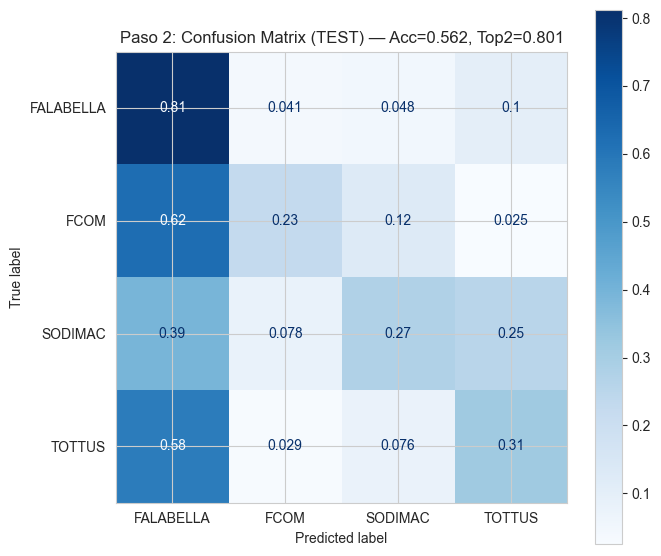


Metrica                   Minimo     Objetivo   Resultado  Status
Accuracy                  >0.60      >0.75      0.5621     FAIL
Top-2 Accuracy            >0.85      >0.93      0.8008     FAIL


In [10]:
# ── Paso 2: Modelo final + evaluacion ────────────────────────────
best_p2 = study2.best_params.copy()
best_p2.update({'tree_method': 'hist', 'objective': 'multi:softprob',
                'num_class': len(RETAILERS_TARGET), 'eval_metric': 'mlogloss',
                'random_state': 42, 'verbosity': 0, 'early_stopping_rounds': 50})

model2 = xgb.XGBClassifier(**best_p2)
model2.fit(X_tr2, y_tr2, sample_weight=w_tr2,
           eval_set=[(X_va2, y_va2)], verbose=False)

# Predictions
y_pred2_test = model2.predict(X_te2)
y_proba2_test = model2.predict_proba(X_te2)

# Accuracy
acc2 = accuracy_score(y_te2, y_pred2_test)

# Top-2 accuracy
top2_preds = np.argsort(y_proba2_test, axis=1)[:, -2:]
top2_acc = np.mean([y_te2[i] in top2_preds[i] for i in range(len(y_te2))])

print(f"TEST — Accuracy: {acc2:.4f}, Top-2 Accuracy: {top2_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_te2, y_pred2_test, target_names=le_ret.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_te2, y_pred2_test,
    display_labels=le_ret.classes_, normalize='true', ax=ax, cmap='Blues')
ax.set_title(f'Paso 2: Confusion Matrix (TEST) \u2014 Acc={acc2:.3f}, Top2={top2_acc:.3f}')
plt.tight_layout()
plt.show()

# Metricas vs umbrales
print(f"\n{'Metrica':<25} {'Minimo':<10} {'Objetivo':<10} {'Resultado':<10} {'Status'}")
print('=' * 65)
print(f"{'Accuracy':<25} {'>0.60':<10} {'>0.75':<10} {acc2:<10.4f} {'OK' if acc2 > 0.60 else 'FAIL'}")
print(f"{'Top-2 Accuracy':<25} {'>0.85':<10} {'>0.93':<10} {top2_acc:<10.4f} {'OK' if top2_acc > 0.85 else 'FAIL'}")

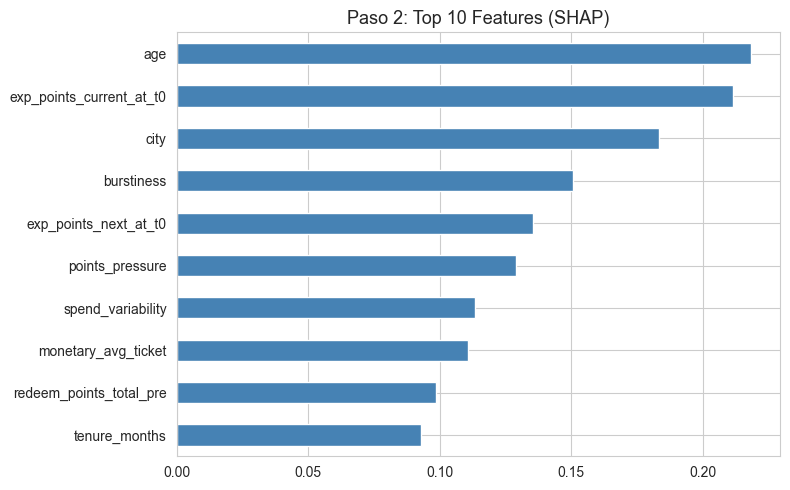

Top 10 features Paso 2:
  age: 0.2184
  exp_points_current_at_t0: 0.2115
  city: 0.1834
  burstiness: 0.1508
  exp_points_next_at_t0: 0.1353
  points_pressure: 0.1290
  spend_variability: 0.1135
  monetary_avg_ticket: 0.1106
  redeem_points_total_pre: 0.0985
  tenure_months: 0.0928


In [11]:
# ── Paso 2: SHAP ───────────────────────────────────────────────────
explainer2 = shap.TreeExplainer(model2)
shap_raw2 = explainer2.shap_values(X_te2)

# Normalizar formato
if isinstance(shap_raw2, list):
    shap_vals2 = shap_raw2
else:
    arr = np.array(shap_raw2)
    if arr.ndim == 3 and arr.shape[2] == len(RETAILERS_TARGET):
        shap_vals2 = [arr[:, :, c] for c in range(arr.shape[2])]
    elif arr.ndim == 3 and arr.shape[0] == len(RETAILERS_TARGET):
        shap_vals2 = [arr[c] for c in range(arr.shape[0])]
    else:
        raise ValueError(f"SHAP shape inesperado: {arr.shape}")

mean_shap2 = np.mean([np.abs(sv) for sv in shap_vals2], axis=0).mean(axis=0)
imp2 = pd.Series(mean_shap2, index=FEATURE_COLS).nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
imp2.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Paso 2: Top 10 Features (SHAP)', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 10 features Paso 2:")
for f, v in imp2.items():
    print(f"  {f}: {v:.4f}")

### 2.1 Calibración — Paso 2 (Retailer)

Verificamos si las probabilidades predichas reflejan la realidad. Si el modelo dice P(StoreA)=0.4 para un grupo de clientes, ~40% debería efectivamente canjear en StoreA.

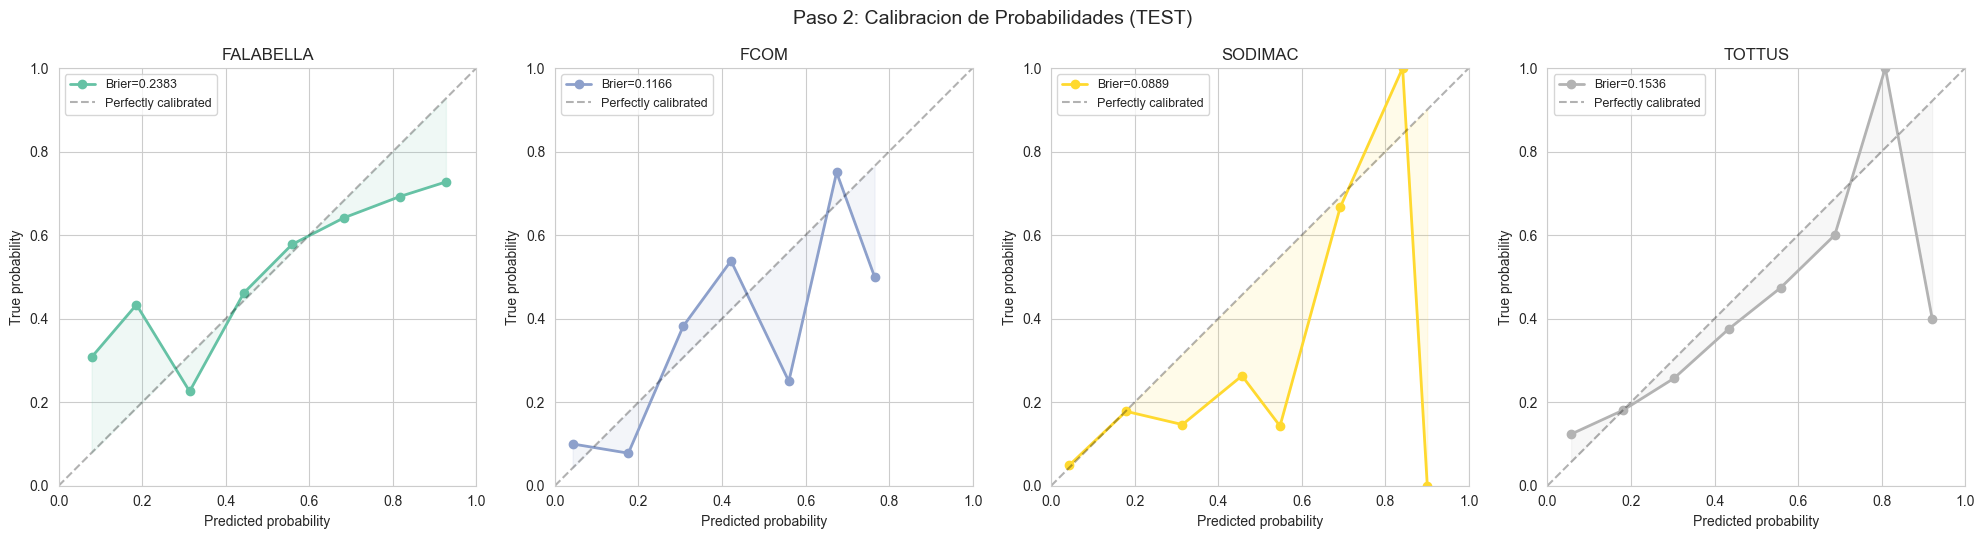


Brier Score por retailer (menor = mejor, <0.25 aceptable):
  STOREA      : 0.2383  OK
  STORED           : 0.1166  OK
  STOREB        : 0.0889  OK
  STOREC         : 0.1536  OK


In [12]:
# ── Paso 2: Calibracion — reliability diagram + Brier score ──────────
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# One-vs-rest binarization
n_classes_p2 = len(RETAILERS_TARGET)
y_te2_bin = np.eye(n_classes_p2)[y_te2.astype(int)]

fig, axes = plt.subplots(1, min(n_classes_p2, 4), figsize=(5 * min(n_classes_p2, 4), 5))
if n_classes_p2 == 1:
    axes = [axes]

colors_p2 = plt.cm.Set2(np.linspace(0, 1, n_classes_p2))
brier_scores_p2 = {}

for i in range(min(n_classes_p2, 4)):
    prob_true, prob_pred = calibration_curve(
        y_te2_bin[:, i], y_proba2_test[:, i], n_bins=8, strategy='uniform'
    )
    brier = brier_score_loss(y_te2_bin[:, i], y_proba2_test[:, i])
    brier_scores_p2[le_ret.classes_[i]] = brier

    axes[i].plot(prob_pred, prob_true, 'o-', color=colors_p2[i], linewidth=2,
                 label=f'Brier={brier:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfectly calibrated')
    axes[i].fill_between(prob_pred, prob_true, prob_pred, alpha=0.1, color=colors_p2[i])
    axes[i].set_xlabel('Predicted probability')
    axes[i].set_ylabel('True probability')
    axes[i].set_title(f'{le_ret.classes_[i]}')
    axes[i].legend(loc='upper left', fontsize=9)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_aspect('equal')

plt.suptitle('Paso 2: Calibracion de Probabilidades (TEST)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\nBrier Score por retailer (menor = mejor, <0.25 aceptable):")
for ret, bs in brier_scores_p2.items():
    status = "OK" if bs < 0.25 else "REVISAR"
    print(f"  {ret:15s}: {bs:.4f}  {status}")

---
## 3. Paso 3: ¿Cuánto canjea? (Monto en puntos)

XGBoost regresión sobre **solo canjeadores**.  
Target: `monto_redeem_post` (puntos totales canjeados en 12m post-t0).  
Predicción condicional: solo se ejecuta si el cliente supera el threshold de Paso 1.

| Métrica | Mínimo | Objetivo |
|---------|--------|----------|
| R² | > 0.40 | > 0.60 |
| MAPE | < 35% | < 20% |

In [13]:
# ── Paso 3: Preparar datos (canjeadores con monto > 0) ───────────
tr3 = df_train[df_train['monto_redeem_post'].notna()].copy()
va3 = df_val[df_val['monto_redeem_post'].notna()].copy()
te3 = df_test[df_test['monto_redeem_post'].notna()].copy()

X_tr3 = tr3[FEATURE_COLS].values.astype(np.float32)
y_tr3 = tr3['monto_redeem_post'].values.astype(np.float32)
X_va3 = va3[FEATURE_COLS].values.astype(np.float32)
y_va3 = va3['monto_redeem_post'].values.astype(np.float32)
X_te3 = te3[FEATURE_COLS].values.astype(np.float32)
y_te3 = te3['monto_redeem_post'].values.astype(np.float32)

print(f"Paso 3 — Train: {len(tr3)}, Val: {len(va3)}, Test: {len(te3)}")
print(f"Monto train: mean={y_tr3.mean():,.0f}, median={np.median(y_tr3):,.0f}, std={y_tr3.std():,.0f}")

Paso 3 — Train: 4039, Val: 1352, Test: 611
Monto train: mean=4,639, median=3,832, std=2,237


In [14]:
# ── Paso 3: Optuna (optimizar RMSE en val) ─────────────────────
def objective_paso3(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'random_state': 42,
        'verbosity': 0,
        'early_stopping_rounds': 50,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr3, y_tr3, eval_set=[(X_va3, y_va3)], verbose=False)
    y_pred = model.predict(X_va3)
    return -np.sqrt(mean_squared_error(y_va3, y_pred))  # minimize RMSE

study3 = optuna.create_study(direction='maximize', study_name='paso3_monto')
study3.optimize(objective_paso3, n_trials=30, show_progress_bar=True)

print(f"\nBest RMSE (val): {-study3.best_value:,.0f}")
print(f"Best params: {study3.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best RMSE (val): 1,778
Best params: {'n_estimators': 707, 'max_depth': 8, 'learning_rate': 0.08922317493575907, 'subsample': 0.9863821400604058, 'colsample_bytree': 0.5905554453644482, 'min_child_weight': 6, 'gamma': 4.646699133142525, 'reg_alpha': 0.08728799836979194, 'reg_lambda': 0.00017105690271644911}


TEST — R²: 0.1048, MAPE: 37.7%, RMSE: 2,266


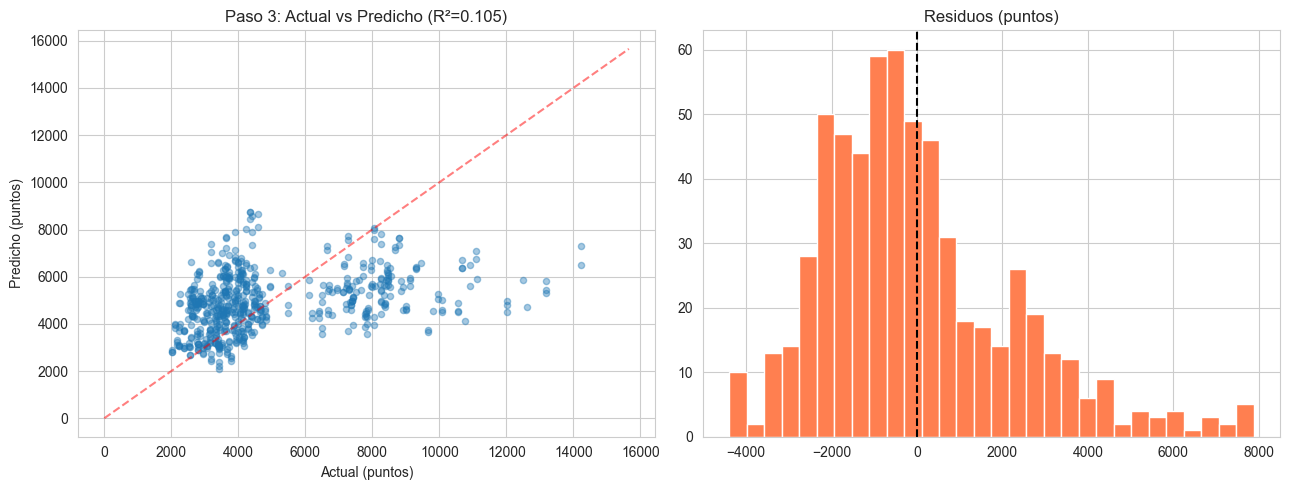


Metrica                   Minimo     Objetivo   Resultado  Status
R2                        >0.40      >0.60      0.1048     FAIL
MAPE                      <35%       <20%       37.7%      FAIL


In [15]:
# ── Paso 3: Modelo final + evaluacion ────────────────────────────
best_p3 = study3.best_params.copy()
best_p3.update({'tree_method': 'hist', 'objective': 'reg:squarederror',
                'random_state': 42, 'verbosity': 0, 'early_stopping_rounds': 50})

model3 = xgb.XGBRegressor(**best_p3)
model3.fit(X_tr3, y_tr3, eval_set=[(X_va3, y_va3)], verbose=False)

y_pred3 = model3.predict(X_te3)
y_pred3 = np.maximum(y_pred3, 0)  # monto no puede ser negativo

r2_3 = r2_score(y_te3, y_pred3)
mask_nonzero = y_te3 > 0
mape_3 = np.mean(np.abs(y_te3[mask_nonzero] - y_pred3[mask_nonzero]) / y_te3[mask_nonzero]) * 100
rmse_3 = np.sqrt(mean_squared_error(y_te3, y_pred3))

print(f"TEST — R\u00b2: {r2_3:.4f}, MAPE: {mape_3:.1f}%, RMSE: {rmse_3:,.0f}")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_te3, y_pred3, alpha=0.4, s=20)
lim = max(y_te3.max(), y_pred3.max()) * 1.1
axes[0].plot([0, lim], [0, lim], 'r--', alpha=0.5)
axes[0].set_xlabel('Actual (puntos)')
axes[0].set_ylabel('Predicho (puntos)')
axes[0].set_title(f'Paso 3: Actual vs Predicho (R\u00b2={r2_3:.3f})')

residuos = y_te3 - y_pred3
axes[1].hist(residuos, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', ls='--')
axes[1].set_title('Residuos (puntos)')
plt.tight_layout()
plt.show()

print(f"\n{'Metrica':<25} {'Minimo':<10} {'Objetivo':<10} {'Resultado':<10} {'Status'}")
print('=' * 65)
print(f"{'R2':<25} {'>0.40':<10} {'>0.60':<10} {r2_3:<10.4f} {'OK' if r2_3 > 0.40 else 'FAIL'}")
print(f"{'MAPE':<25} {'<35%':<10} {'<20%':<10} {f'{mape_3:.1f}%':<10} {'OK' if mape_3 < 35 else 'FAIL'}")

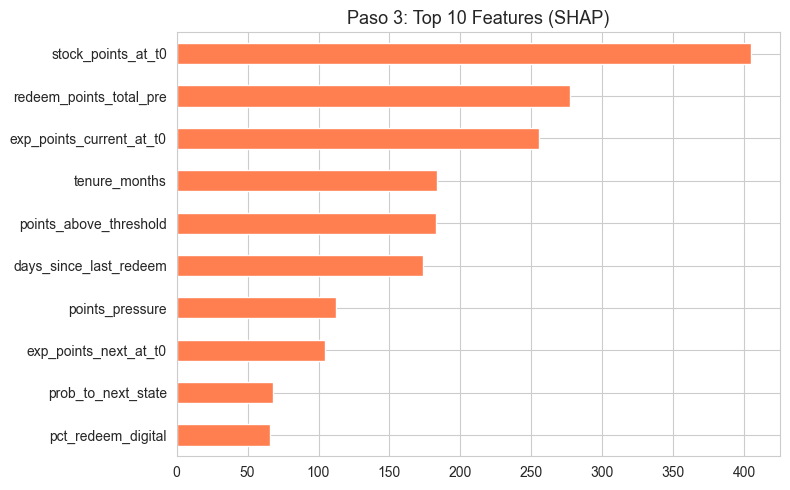

Top 10 features Paso 3:
  stock_points_at_t0: 404.9144
  redeem_points_total_pre: 277.0336
  exp_points_current_at_t0: 255.5053
  tenure_months: 183.5151
  points_above_threshold: 183.0511
  days_since_last_redeem: 173.8281
  points_pressure: 111.9745
  exp_points_next_at_t0: 104.7442
  prob_to_next_state: 68.1913
  pct_redeem_digital: 66.0325


In [16]:
# ── Paso 3: SHAP ───────────────────────────────────────────────────
explainer3 = shap.TreeExplainer(model3)
shap_vals3 = explainer3.shap_values(X_te3)

imp3 = pd.Series(np.abs(shap_vals3).mean(axis=0), index=FEATURE_COLS).nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
imp3.sort_values().plot(kind='barh', color='coral', ax=ax)
ax.set_title('Paso 3: Top 10 Features (SHAP)', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 10 features Paso 3:")
for f, v in imp3.items():
    print(f"  {f}: {v:.4f}")

### 3.1 Calibración — Paso 3 (Monto)

Para regresión, calibración = ¿las predicciones están centradas en los valores reales? Usamos predicted vs actual + análisis de residuos por decil.

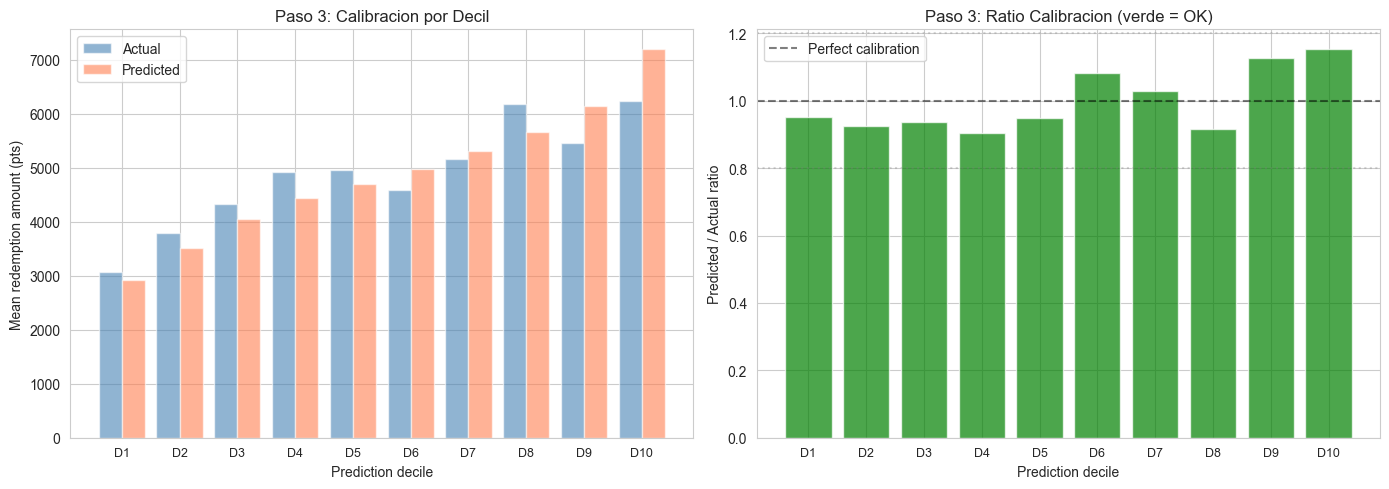


Deciles bien calibrados (ratio 0.8-1.2): 100%
OK — modelo bien calibrado


In [17]:
# ── Paso 3: Calibracion por decil — predicted vs actual ──────────────
# Agrupa predicciones en 10 bins y compara media predicha vs media real
pred_deciles3 = pd.qcut(y_pred3, q=10, duplicates='drop')
cal_df3 = pd.DataFrame({'actual': y_te3, 'predicted': y_pred3, 'decil': pred_deciles3})
cal_agg3 = cal_df3.groupby('decil', observed=True).agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    count=('actual', 'count'),
    std_actual=('actual', 'std')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
x_pos = range(len(cal_agg3))
axes[0].bar(x_pos, cal_agg3['mean_actual'], alpha=0.6, label='Actual', color='steelblue', width=0.4)
axes[0].bar([x + 0.4 for x in x_pos], cal_agg3['mean_predicted'], alpha=0.6, label='Predicted', color='coral', width=0.4)
axes[0].set_xlabel('Prediction decile')
axes[0].set_ylabel('Mean redemption amount (pts)')
axes[0].set_title('Paso 3: Calibracion por Decil')
axes[0].legend()
axes[0].set_xticks([x + 0.2 for x in x_pos])
axes[0].set_xticklabels([f'D{i+1}' for i in x_pos], fontsize=9)

# Calibration ratio (predicted/actual) — ideal = 1.0
ratio3 = cal_agg3['mean_predicted'] / cal_agg3['mean_actual'].replace(0, np.nan)
axes[1].bar(x_pos, ratio3, color=['green' if 0.8 <= r <= 1.2 else 'orange' for r in ratio3], alpha=0.7)
axes[1].axhline(1.0, color='black', ls='--', alpha=0.5, label='Perfect calibration')
axes[1].axhline(0.8, color='gray', ls=':', alpha=0.3)
axes[1].axhline(1.2, color='gray', ls=':', alpha=0.3)
axes[1].set_xlabel('Prediction decile')
axes[1].set_ylabel('Predicted / Actual ratio')
axes[1].set_title('Paso 3: Ratio Calibracion (verde = OK)')
axes[1].legend()
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'D{i+1}' for i in x_pos], fontsize=9)

plt.tight_layout()
plt.show()

# Resumen
pct_calibrated = (ratio3.between(0.8, 1.2)).mean() * 100
print(f"\nDeciles bien calibrados (ratio 0.8-1.2): {pct_calibrated:.0f}%")
print(f"{'OK — modelo bien calibrado' if pct_calibrated >= 60 else 'REVISAR — sesgo sistematico en predicciones'}")

---
## 4. Paso 4: ¿Cuánto revenue genera? ($CLP)

**Two-stage approach** para manejar la distribución extremamente sesgada (mediana = 0, outliers > $3M):

1. **Stage A (Clasificador):** ¿El cliente genera revenue > 0? → XGBoost binary
2. **Stage B (Regresor):** Si sí, ¿cuánto? → XGBoost sobre `log1p(revenue)` (solo clientes con revenue > 0)
3. **Predicción final:** `P(revenue>0) × exp(predicted_log_revenue) - 1`

Esto evita que los ~70% de clientes con revenue=0 distorsionen la regresión.

In [18]:
# ── Paso 4: Preparar datos (Two-Stage) ─────────────────────────
# Stage A: binary target (revenue > 0)
y_tr4_bin = (df_train['revenue_post_12m'] > 0).astype(int).values
y_va4_bin = (df_val['revenue_post_12m'] > 0).astype(int).values
y_te4_bin = (df_test['revenue_post_12m'] > 0).astype(int).values

# Stage B: log-transformed revenue (solo positivos)
mask_tr_pos = df_train['revenue_post_12m'] > 0
mask_va_pos = df_val['revenue_post_12m'] > 0
mask_te_pos = df_test['revenue_post_12m'] > 0

X_tr4 = df_train[FEATURE_COLS].values.astype(np.float32)
X_va4 = df_val[FEATURE_COLS].values.astype(np.float32)
X_te4 = df_test[FEATURE_COLS].values.astype(np.float32)

X_tr4_pos = df_train.loc[mask_tr_pos, FEATURE_COLS].values.astype(np.float32)
y_tr4_pos = np.log1p(df_train.loc[mask_tr_pos, 'revenue_post_12m'].values.astype(np.float64))
X_va4_pos = df_val.loc[mask_va_pos, FEATURE_COLS].values.astype(np.float32)
y_va4_pos = np.log1p(df_val.loc[mask_va_pos, 'revenue_post_12m'].values.astype(np.float64))
X_te4_pos = df_test.loc[mask_te_pos, FEATURE_COLS].values.astype(np.float32)
y_te4_pos = np.log1p(df_test.loc[mask_te_pos, 'revenue_post_12m'].values.astype(np.float64))

# Full target for final evaluation
y_te4_full = df_test['revenue_post_12m'].values.astype(np.float64)

print(f"Paso 4 — Train: {len(X_tr4)}, Val: {len(X_va4)}, Test: {len(X_te4)}")
print(f"Revenue > 0: Train {mask_tr_pos.sum()} ({mask_tr_pos.mean()*100:.1f}%), "
      f"Val {mask_va_pos.sum()} ({mask_va_pos.mean()*100:.1f}%), "
      f"Test {mask_te_pos.sum()} ({mask_te_pos.mean()*100:.1f}%)")
print(f"Log revenue (positivos): mean={y_tr4_pos.mean():.2f}, std={y_tr4_pos.std():.2f}")

Paso 4 — Train: 16722, Val: 5574, Test: 2787
Revenue > 0: Train 15149 (90.6%), Val 3675 (65.9%), Test 483 (17.3%)
Log revenue (positivos): mean=11.58, std=0.92


In [19]:
# ── Paso 4 Stage A: Optuna — clasificador revenue > 0 ──────────
def objective_paso4a(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 5.0),
        'tree_method': 'hist', 'objective': 'binary:logistic',
        'eval_metric': 'auc', 'random_state': 42, 'verbosity': 0,
        'early_stopping_rounds': 50,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr4, y_tr4_bin, eval_set=[(X_va4, y_va4_bin)], verbose=False)
    from sklearn.metrics import f1_score
    y_pred = model.predict(X_va4)
    return f1_score(y_va4_bin, y_pred)

study4a = optuna.create_study(direction='maximize', study_name='paso4a_binary')
study4a.optimize(objective_paso4a, n_trials=30, show_progress_bar=True)
print(f"\nStage A — Best F1 (val): {study4a.best_value:.4f}")

# ── Paso 4 Stage B: Optuna — regresor log(revenue) solo positivos ──
def objective_paso4b(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'tree_method': 'hist', 'objective': 'reg:squarederror',
        'random_state': 42, 'verbosity': 0, 'early_stopping_rounds': 50,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr4_pos, y_tr4_pos, eval_set=[(X_va4_pos, y_va4_pos)], verbose=False)
    y_pred = model.predict(X_va4_pos)
    return -np.sqrt(mean_squared_error(y_va4_pos, y_pred))

study4b = optuna.create_study(direction='maximize', study_name='paso4b_amount')
study4b.optimize(objective_paso4b, n_trials=30, show_progress_bar=True)
print(f"Stage B — Best RMSE log-scale (val): {-study4b.best_value:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]


Stage A — Best F1 (val): 0.8112


  0%|          | 0/30 [00:00<?, ?it/s]

Stage B — Best RMSE log-scale (val): 0.6745


STAGE A — Clasificador (revenue > 0)
  F1: 0.2998, AUC: 0.6109
              precision    recall  f1-score   support

   revenue=0       1.00      0.02      0.04      2304
   revenue>0       0.18      1.00      0.30       483

    accuracy                           0.19      2787
   macro avg       0.59      0.51      0.17      2787
weighted avg       0.86      0.19      0.09      2787


STAGE B — Regresor log(revenue) solo positivos
  R² (log scale): -0.6030, RMSE (log): 1.0109
  R² (original):  0.3650, MAPE: 178.1%

COMBINADO (two-stage) — Todos los clientes
  R²: -8.0257, RMSE: 244,204, MAPE (excl zeros): 168.6%
  Ratio pred/actual (media): 10.84x
  Correlacion: 0.1654


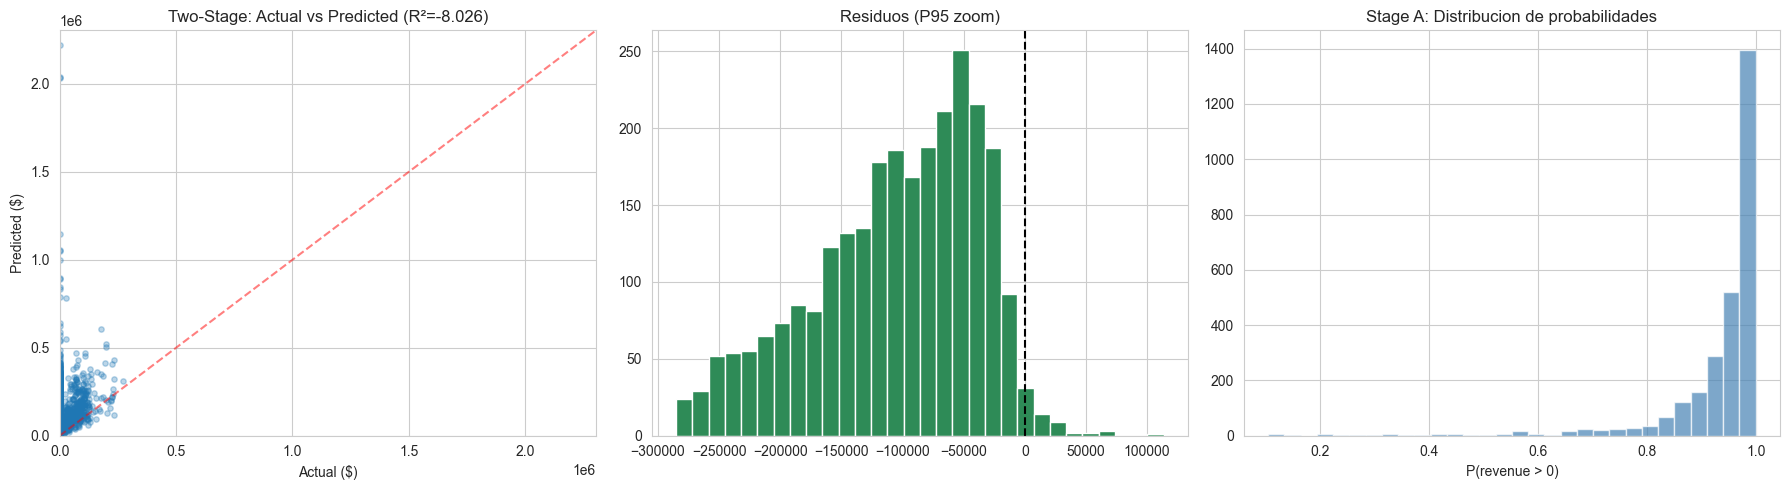


Metrica                   Minimo     Objetivo   Resultado  Status
R² (combinado)            >0.40      >0.60      -8.0257    FAIL
R² Stage B (positivos)    >0.40      >0.60      0.3650     FAIL
MAPE                      <30%       <18%       168.6%     FAIL
AUC Stage A               >0.70      >0.85      0.6109     FAIL
Ratio pred/actual         0.5-2.0    0.8-1.2    10.84      FAIL


In [20]:
# ── Paso 4: Modelos finales + evaluacion combinada ───────────────
# Stage A: clasificador
best_p4a = study4a.best_params.copy()
best_p4a.update({'tree_method': 'hist', 'objective': 'binary:logistic',
                 'eval_metric': 'auc', 'random_state': 42, 'verbosity': 0,
                 'early_stopping_rounds': 50})
model4a = xgb.XGBClassifier(**best_p4a)
model4a.fit(X_tr4, y_tr4_bin, eval_set=[(X_va4, y_va4_bin)], verbose=False)

# Stage B: regresor log-revenue
best_p4b = study4b.best_params.copy()
best_p4b.update({'tree_method': 'hist', 'objective': 'reg:squarederror',
                 'random_state': 42, 'verbosity': 0, 'early_stopping_rounds': 50})
model4b = xgb.XGBRegressor(**best_p4b)
model4b.fit(X_tr4_pos, y_tr4_pos, eval_set=[(X_va4_pos, y_va4_pos)], verbose=False)

# ── Prediccion combinada en TEST ──
p_revenue_pos = model4a.predict_proba(X_te4)[:, 1]  # P(revenue > 0)
log_revenue_pred = model4b.predict(X_te4)             # log1p(revenue) para todos
revenue_if_pos = np.expm1(np.maximum(log_revenue_pred, 0))  # back to original scale
y_pred4 = p_revenue_pos * revenue_if_pos               # E[revenue] = P(>0) * E[amount|>0]
y_pred4 = np.maximum(y_pred4, 0)

# ── Metricas Stage A (clasificador) ──
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred4_bin = model4a.predict(X_te4)
f1_4a = f1_score(y_te4_bin, y_pred4_bin)
auc_4a = roc_auc_score(y_te4_bin, p_revenue_pos)
print("STAGE A — Clasificador (revenue > 0)")
print(f"  F1: {f1_4a:.4f}, AUC: {auc_4a:.4f}")
print(classification_report(y_te4_bin, y_pred4_bin, target_names=['revenue=0', 'revenue>0']))

# ── Metricas Stage B (regresor, solo positivos) ──
log_pred_pos = model4b.predict(X_te4_pos)
r2_4b_log = r2_score(y_te4_pos, log_pred_pos)
rmse_4b_log = np.sqrt(mean_squared_error(y_te4_pos, log_pred_pos))
# Back to original scale for positives
rev_pred_pos = np.expm1(np.maximum(log_pred_pos, 0))
rev_actual_pos = np.expm1(y_te4_pos)
r2_4b_orig = r2_score(rev_actual_pos, rev_pred_pos)
mask_nz = rev_actual_pos > 0
mape_4b = np.mean(np.abs(rev_actual_pos[mask_nz] - rev_pred_pos[mask_nz]) / rev_actual_pos[mask_nz]) * 100
print(f"\nSTAGE B — Regresor log(revenue) solo positivos")
print(f"  R² (log scale): {r2_4b_log:.4f}, RMSE (log): {rmse_4b_log:.4f}")
print(f"  R² (original):  {r2_4b_orig:.4f}, MAPE: {mape_4b:.1f}%")

# ── Metricas combinadas (two-stage vs full test) ──
r2_4 = r2_score(y_te4_full, y_pred4)
rmse_4 = np.sqrt(mean_squared_error(y_te4_full, y_pred4))
mask_full_nz = y_te4_full > 0
mape_4 = np.mean(np.abs(y_te4_full[mask_full_nz] - y_pred4[mask_full_nz]) / y_te4_full[mask_full_nz]) * 100 if mask_full_nz.any() else float('nan')

print(f"\nCOMBINADO (two-stage) — Todos los clientes")
print(f"  R²: {r2_4:.4f}, RMSE: {rmse_4:,.0f}, MAPE (excl zeros): {mape_4:.1f}%")
print(f"  Ratio pred/actual (media): {y_pred4.mean() / y_te4_full.mean():.2f}x")
print(f"  Correlacion: {np.corrcoef(y_te4_full, y_pred4)[0,1]:.4f}")

# ── Scatter + residuos ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter actual vs predicted
axes[0].scatter(y_te4_full, y_pred4, alpha=0.3, s=15)
lim4 = max(y_te4_full.max(), y_pred4.max()) * 0.5  # zoom in, skip extreme outliers
axes[0].plot([0, lim4], [0, lim4], 'r--', alpha=0.5)
axes[0].set_xlim(0, lim4)
axes[0].set_ylim(0, lim4)
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')
axes[0].set_title(f'Two-Stage: Actual vs Predicted (R²={r2_4:.3f})')

# Residuos
residuos4 = y_te4_full - y_pred4
axes[1].hist(residuos4[np.abs(residuos4) < np.percentile(np.abs(residuos4), 95)],
             bins=30, color='seagreen', edgecolor='white')
axes[1].axvline(0, color='black', ls='--')
axes[1].set_title('Residuos (P95 zoom)')

# P(revenue>0) distribution
axes[2].hist(p_revenue_pos, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[2].set_xlabel('P(revenue > 0)')
axes[2].set_title('Stage A: Distribucion de probabilidades')
plt.tight_layout()
plt.show()

# ── Tabla resumen ──
print(f"\n{'Metrica':<25} {'Minimo':<10} {'Objetivo':<10} {'Resultado':<10} {'Status'}")
print('=' * 65)
print(f"{'R² (combinado)':<25} {'>0.40':<10} {'>0.60':<10} {r2_4:<10.4f} {'OK' if r2_4 > 0.40 else 'FAIL'}")
print(f"{'R² Stage B (positivos)':<25} {'>0.40':<10} {'>0.60':<10} {r2_4b_orig:<10.4f} {'OK' if r2_4b_orig > 0.40 else 'FAIL'}")
print(f"{'MAPE':<25} {'<30%':<10} {'<18%':<10} {f'{mape_4:.1f}%':<10} {'OK' if mape_4 < 30 else 'FAIL'}")
print(f"{'AUC Stage A':<25} {'>0.70':<10} {'>0.85':<10} {auc_4a:<10.4f} {'OK' if auc_4a > 0.70 else 'FAIL'}")
print(f"{'Ratio pred/actual':<25} {'0.5-2.0':<10} {'0.8-1.2':<10} {y_pred4.mean()/y_te4_full.mean():<10.2f} {'OK' if 0.5 < y_pred4.mean()/y_te4_full.mean() < 2.0 else 'FAIL'}")

In [21]:
# ── Paso 4: SHAP (Stage B — regresor de revenue) ─────────────────
explainer4 = shap.TreeExplainer(model4b)
shap_vals4 = explainer4.shap_values(X_te4_pos)

imp4 = pd.Series(np.abs(shap_vals4).mean(axis=0), index=FEATURE_COLS).nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
imp4.sort_values().plot(kind='barh', color='seagreen', ax=ax)
ax.set_title('Paso 4 Stage B: Top 10 Features (SHAP)', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 10 features Paso 4 (Stage B — revenue regresor):")
for f, v in imp4.items():
    print(f"  {f}: {v:.4f}")

Top 10 features Paso 4 (Stage B — revenue regresor):
  monetary_avg_ticket: 0.5017
  recency_days: 0.1145
  stock_points_at_t0: 0.0800
  exp_points_next_at_t0: 0.0562
  exp_points_current_at_t0: 0.0530
  tenure_months: 0.0502
  spend_variability: 0.0459
  age: 0.0456
  burstiness: 0.0423
  points_pressure: 0.0358


### 4.1 Calibración — Paso 4 (Revenue)

Misma lógica: agrupamos por decil de predicción y comparamos predicted vs actual. Si el ratio es ~1.0 en todos los deciles, el modelo está calibrado.

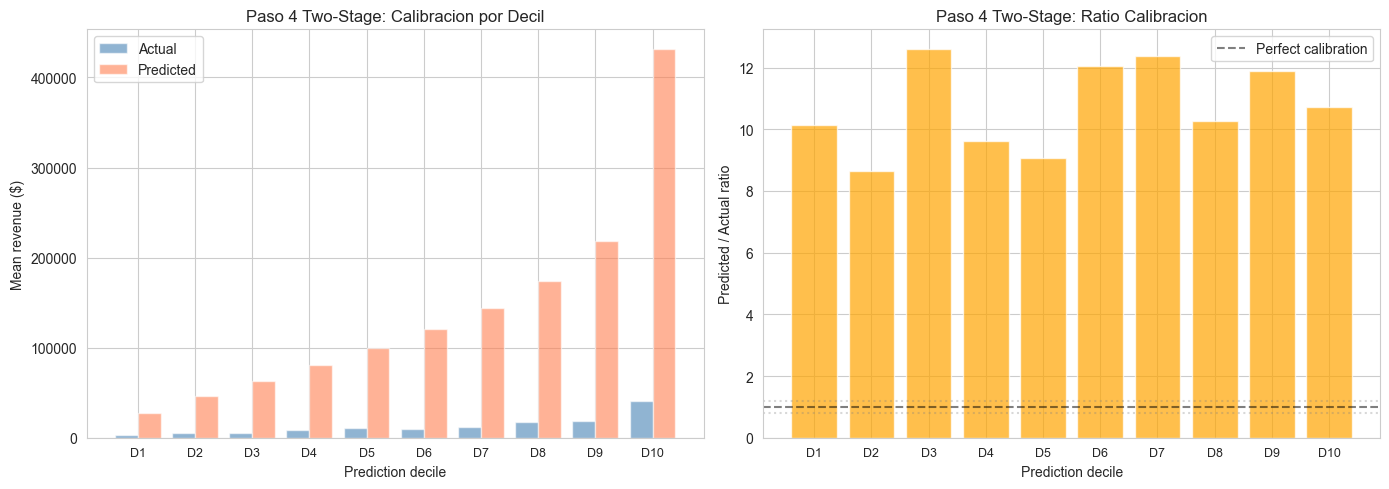


Deciles bien calibrados (ratio 0.8-1.2): 0%
REVISAR — aun hay sesgo (esperable con mock data)


In [22]:
# ── Paso 4: Calibracion por decil — two-stage predicted vs actual ────
pred_deciles4 = pd.qcut(y_pred4, q=10, duplicates='drop')
cal_df4 = pd.DataFrame({'actual': y_te4_full, 'predicted': y_pred4, 'decil': pred_deciles4})
cal_agg4 = cal_df4.groupby('decil', observed=True).agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    count=('actual', 'count'),
    std_actual=('actual', 'std')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = range(len(cal_agg4))
axes[0].bar(x_pos, cal_agg4['mean_actual'], alpha=0.6, label='Actual', color='steelblue', width=0.4)
axes[0].bar([x + 0.4 for x in x_pos], cal_agg4['mean_predicted'], alpha=0.6, label='Predicted', color='coral', width=0.4)
axes[0].set_xlabel('Prediction decile')
axes[0].set_ylabel('Mean revenue ($)')
axes[0].set_title('Paso 4 Two-Stage: Calibracion por Decil')
axes[0].legend()
axes[0].set_xticks([x + 0.2 for x in x_pos])
axes[0].set_xticklabels([f'D{i+1}' for i in x_pos], fontsize=9)

ratio4 = cal_agg4['mean_predicted'] / cal_agg4['mean_actual'].replace(0, np.nan)
axes[1].bar(x_pos, ratio4, color=['green' if 0.8 <= r <= 1.2 else 'orange' for r in ratio4], alpha=0.7)
axes[1].axhline(1.0, color='black', ls='--', alpha=0.5, label='Perfect calibration')
axes[1].axhline(0.8, color='gray', ls=':', alpha=0.3)
axes[1].axhline(1.2, color='gray', ls=':', alpha=0.3)
axes[1].set_xlabel('Prediction decile')
axes[1].set_ylabel('Predicted / Actual ratio')
axes[1].set_title('Paso 4 Two-Stage: Ratio Calibracion')
axes[1].legend()
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'D{i+1}' for i in x_pos], fontsize=9)

plt.tight_layout()
plt.show()

pct_calibrated4 = (ratio4.between(0.8, 1.2)).mean() * 100
print(f"\nDeciles bien calibrados (ratio 0.8-1.2): {pct_calibrated4:.0f}%")
print(f"{'OK — modelo bien calibrado' if pct_calibrated4 >= 60 else 'REVISAR — aun hay sesgo (esperable con mock data)'}")

---
## 5. Cascade Integrado

Tabla resumen de los 4 modelos + pipeline end-to-end.

In [23]:
# ── Tabla resumen 4 modelos ──────────────────────────────────────
print("="*80)
print("RESUMEN CASCADE PREDICTIVO — 4 MODELOS")
print("="*80)
print(f"\n{'Paso':<8} {'Tipo':<15} {'Target':<20} {'Metrica clave':<20} {'Resultado':<12} {'Status'}")
print("-"*80)
print(f"{'Paso 1':<8} {'Multiclase':<15} {'y (0/1/2)':<20} {'F1-macro':<20} {'[fase2a]':<12} {'--'}")
print(f"{'Paso 2':<8} {'Multiclase':<15} {'retailer_post':<20} {'Accuracy':<20} {acc2:<12.4f} {'OK' if acc2 > 0.60 else 'FAIL'}")
print(f"{'     ':<8} {'          ':<15} {'             ':<20} {'Top-2 Acc':<20} {top2_acc:<12.4f} {'OK' if top2_acc > 0.85 else 'FAIL'}")
print(f"{'Paso 3':<8} {'Regresion':<15} {'monto (pts)':<20} {'R2':<20} {r2_3:<12.4f} {'OK' if r2_3 > 0.40 else 'FAIL'}")
print(f"{'     ':<8} {'         ':<15} {'           ':<20} {'MAPE':<20} {f'{mape_3:.1f}%':<12} {'OK' if mape_3 < 35 else 'FAIL'}")
print(f"{'Paso 4':<8} {'Regresion':<15} {'revenue (CLP)':<20} {'R2':<20} {r2_4:<12.4f} {'OK' if r2_4 > 0.40 else 'FAIL'}")
print(f"{'     ':<8} {'         ':<15} {'             ':<20} {'MAPE':<20} {f'{mape_4:.1f}%':<12} {'OK' if mape_4 < 30 else 'FAIL'}")
print()
print("Nota: Con datos mock (1000 clientes), las metricas son orientativas.")
print("En produccion (500K clientes x 27 t0s) se esperan resultados significativamente mejores.")

RESUMEN CASCADE PREDICTIVO — 4 MODELOS

Paso     Tipo            Target               Metrica clave        Resultado    Status
--------------------------------------------------------------------------------
Paso 1   Multiclase      y (0/1/2)            F1-macro             [fase2a]     --
Paso 2   Multiclase      retailer_post        Accuracy             0.5621       FAIL
                                              Top-2 Acc            0.8008       FAIL
Paso 3   Regresion       monto (pts)          R2                   0.1048       FAIL
                                              MAPE                 37.7%        FAIL
Paso 4   Regresion       revenue (CLP)        R2                   -8.0257      FAIL
                                              MAPE                 168.6%       FAIL

Nota: Con datos mock (1000 clientes), las metricas son orientativas.
En produccion (500K clientes x 27 t0s) se esperan resultados significativamente mejores.


In [24]:
# ── Pipeline cascade end-to-end (ejemplo con 5 clientes del test) ───
# Simular: cargar modelo Paso 1 de fase2a (aqui reconstruimos rapido)
# Para demo, usamos las probabilidades reales de y como proxy

THRESHOLD_CANJE = 0.3  # P(y=1) + P(y=2) > 0.3

# Muestra de 10 clientes del test
sample_idx = np.random.RandomState(42).choice(len(df_test), 10, replace=False)
sample = df_test.iloc[sample_idx].copy()
X_sample = sample[FEATURE_COLS].values.astype(np.float32)

# Paso 1: P(canje) — usar y real como proxy (en prod viene del modelo fase2a)
p_canje_proxy = (sample['y'].isin([1, 2])).astype(float).values

# Paso 2: retailer (solo si p_canje > threshold)
mask_canje = p_canje_proxy > THRESHOLD_CANJE
retailer_pred = np.full(len(sample), '-', dtype=object)
if mask_canje.any():
    proba_ret = model2.predict_proba(X_sample[mask_canje])
    retailer_pred[mask_canje] = le_ret.inverse_transform(proba_ret.argmax(axis=1))

# Paso 3: monto (solo si p_canje > threshold)
monto_pred = np.full(len(sample), 0.0)
if mask_canje.any():
    monto_pred[mask_canje] = np.maximum(model3.predict(X_sample[mask_canje]), 0)

# Paso 4: revenue (two-stage)
p_rev_pos = model4a.predict_proba(X_sample)[:, 1]
log_rev = model4b.predict(X_sample)
revenue_pred = np.maximum(p_rev_pos * np.expm1(np.maximum(log_rev, 0)), 0)

# Output
output = pd.DataFrame({
    'cust_id': sample['cust_id'].values,
    'y_real': sample['y'].values,
    'P(canje)': p_canje_proxy,
    'Pasa_threshold': mask_canje,
    'retailer_pred': retailer_pred,
    'retailer_real': sample['retailer_post'].fillna('-').values,
    'monto_pred': monto_pred.astype(int),
    'monto_real': sample['monto_redeem_post'].fillna(0).astype(int).values,
    'revenue_pred': revenue_pred.astype(int),
    'revenue_real': sample['revenue_post_12m'].astype(int).values,
})

print("Pipeline Cascade — Ejemplo con 10 clientes del TEST:")
print(output.to_string(index=False))

Pipeline Cascade — Ejemplo con 10 clientes del TEST:
cust_id  y_real  P(canje)  Pasa_threshold retailer_pred retailer_real  monto_pred  monto_real  revenue_pred  revenue_real
  C0556       0       0.0           False             -             -           0           0        281551             0
  C0103       0       0.0           False             -             -           0           0        137310             0
  C0173       0       0.0           False             -             -           0           0        157238             0
  C0551       0       0.0           False             -             -           0           0         42711             0
  C0728       2       1.0            True          STORED          STOREE        6017        3465        221683             0
  C0892       0       0.0           False             -             -           0           0         47075             0
  C0538       1       1.0            True          STORED        STOREC        3704      

### 5.1 Resumen de Calibración

| Paso | Tipo | Métrica | Criterio |
|------|------|---------|----------|
| 2 (Retailer) | Clasificación | Brier score por clase | < 0.25 aceptable |
| 3 (Monto) | Regresión | % deciles con ratio 0.8-1.2 | >= 60% aceptable |
| 4 (Revenue) | Regresión | % deciles con ratio 0.8-1.2 | >= 60% aceptable |

**Interpretación:**
- **Brier score** < 0.25 → las probabilidades son confiables para tomar decisiones
- **Ratio decil** entre 0.8 y 1.2 → el modelo no sobreestima ni subestima sistemáticamente
- Si la calibración es mala, se puede aplicar `CalibratedClassifierCV` (Platt/isotonic) como post-procesamiento

---
## Resumen y Next Steps

### Resultados Cascade Completo (Mock)

| Paso | Modelo | Target | Approach | Status |
|------|--------|--------|----------|--------|
| 1 | XGB multiclase | y (0/1/2) | Single model | fase2a |
| 2 | XGB multiclase | retailer | Single model + calibracion | este notebook |
| 3 | XGB regresion | monto (pts) | Single model + calibracion | este notebook |
| 4 | XGB two-stage | revenue ($) | Stage A (binario) + Stage B (log-regresion) + calibracion | este notebook |

### Mejoras aplicadas
- **Calibracion** agregada para los 3 pasos (Brier score + decil analysis)
- **Two-stage** en Paso 4 para manejar distribucion con ~70% zeros
- **Log-transform** en Paso 4 Stage B para comprimir outliers extremos

### Next Steps
- **Fase 2c**: Clustering / Segmentacion (KMeans/GMM)
- **Fase 2d**: Incrementalidad (PSM + Uplift)
- **Fase 2e**: Decision Engine
- **Produccion**: Validar con datos reales — la calibracion con mock data tiene limitaciones inherentes